Project Root: /Users/steven/Documents/Github Repositories/EEG-to-Text_Conformer-Transducer
Raw Data Path: /Users/steven/Documents/Github Repositories/EEG-to-Text_Conformer-Transducer/dataset/raw

Data mapping berhasil di-load! Shape: (1050, 4)
Total subjek: 12
Fungsi pencarian multi-file berhasil didefinisikan.
Mulai membaca SEMUA file BDF untuk 12 subjek...

Memproses BEL (female): Ditemukan 100 file...
Memproses DAM (male): Ditemukan 50 file...
Memproses ERI (male): Ditemukan 50 file...
Memproses EVE (female): Ditemukan 100 file...
Memproses FAR (female): Ditemukan 100 file...
Memproses KEN (female): Ditemukan 100 file...
Memproses LIA (female): Ditemukan 100 file...
Memproses MAR (male): Ditemukan 100 file...
Memproses NAU (male): Ditemukan 100 file...
Memproses RAN (male): Ditemukan 50 file...
Memproses RET (female): Ditemukan 100 file...
Memproses SUL (male): Ditemukan 100 file...
Berhasil di-load ke antrean: 1050 file
Gagal di-load: 0 file

 ANALISIS SPEKTRAL REGIONAL (WELCH'S PS

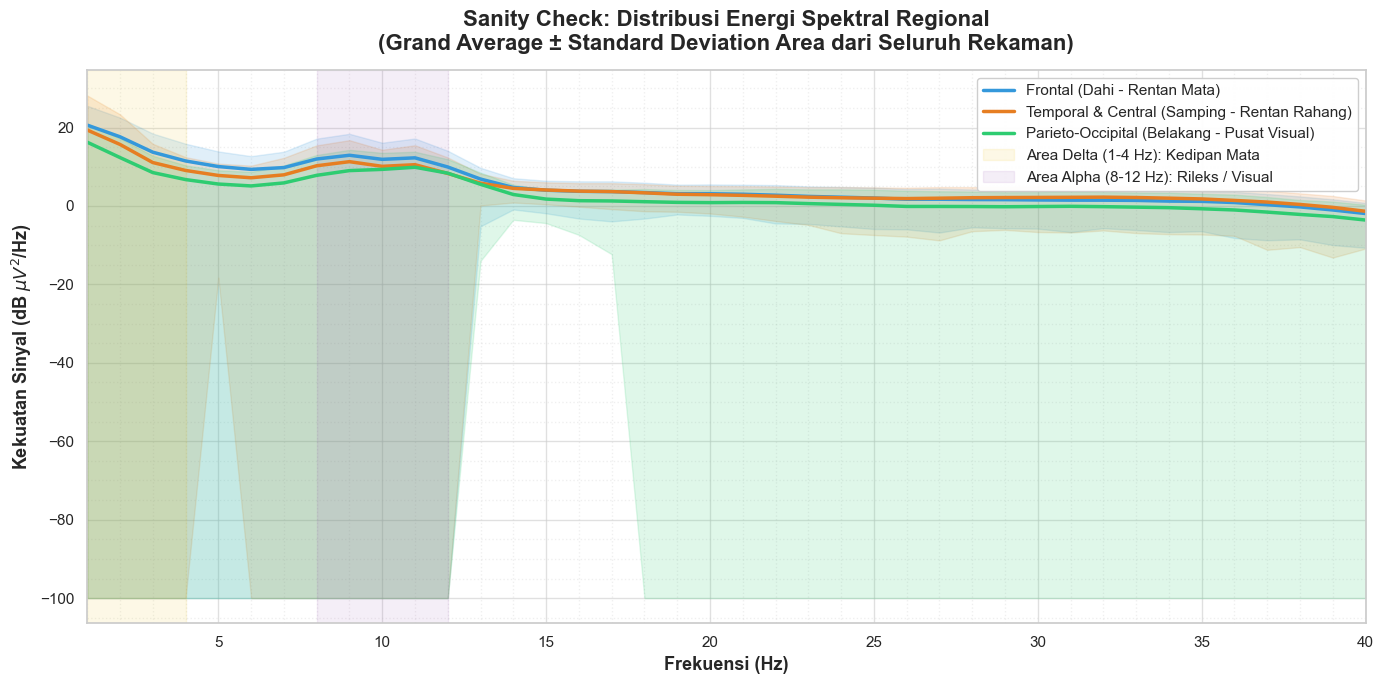

In [ ]:
import pandas as pd
import numpy as np
import os
import mne
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from mne.preprocessing import ICA
from mne_icalabel import label_components
from scipy.stats import linregress
from mne.time_frequency import psd_array_welch

warnings.filterwarnings('ignore')
mne.set_log_level('WARNING') # Mencegah MNE mencetak log terlalu panjang
sns.set_theme(style="whitegrid")

# =====================================================================
# TAHAP 1: KONFIGURASI & LOAD METADATA (KODE ANDA)
# =====================================================================
# Dapatkan path root proyek (Sesuaikan jika Anda memindahkan file notebook)
try:
    notebook_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    # Fallback jika dijalankan murni di cell Jupyter Notebook
    notebook_dir = os.getcwd() 
    
project_root = os.path.abspath(os.path.join(notebook_dir, '../../../'))

cleaned_csv_path = os.path.join(project_root, 'dataset/cleaned_transcript_mapping.csv')
raw_data_path = os.path.join(project_root, 'dataset/raw')

print(f"Project Root: {project_root}")
print(f"Raw Data Path: {raw_data_path}")

# Load data mapping
df = pd.read_csv(cleaned_csv_path)
print(f"\nData mapping berhasil di-load! Shape: {df.shape}")

# Pemetaan Subjek dan Gender
subject_info = df.groupby('subject').first()[['gender']].reset_index()
subject_gender_map = dict(zip(subject_info['subject'], subject_info['gender']))
subjects = sorted(subject_info['subject'].tolist())
print(f"Total subjek: {len(subjects)}")

def get_all_bdf_files(subject, gender, raw_data_path):
    """Mengambil SEMUA path file .bdf yang valid untuk satu subjek"""
    bdf_folder = os.path.join(raw_data_path, gender, subject, 'bdf+')
    bdf_files = []
    try:
        for f in os.listdir(bdf_folder):
            # Filter ganda: Abaikan .csv/.json dan abaikan file tersembunyi macOS (._)
            if f.endswith('.bdf') and not f.startswith('._'):
                bdf_files.append(os.path.join(bdf_folder, f))
    except Exception as e:
        pass
    return sorted(bdf_files)

print("Fungsi pencarian multi-file berhasil didefinisikan.")

all_eeg_records = []
load_success_count = 0
load_failed_count = 0

print(f"Mulai membaca SEMUA file BDF untuk {len(subjects)} subjek...\n")
print("=" * 80)

for subject in subjects:
    gender = subject_gender_map[subject]
    bdf_files = get_all_bdf_files(subject, gender, raw_data_path)
    
    if not bdf_files:
        print(f"✗ {subject} ({gender}): Folder kosong/tidak ditemukan")
        continue
        
    print(f"Memproses {subject} ({gender}): Ditemukan {len(bdf_files)} file...")
    
    for file_path in bdf_files:
        try:
            # Load metadata BDF tanpa me-load seluruh sinyal ke RAM dulu (hemat memori)
            raw = mne.io.read_raw_bdf(file_path, preload=False, verbose=False)
            all_eeg_records.append({
                'subject': subject,
                'gender': gender,
                'file_path': file_path,
                'filename': os.path.basename(file_path),
                'raw': raw,
                'n_channels': raw.info['nchan'],
                'sampling_rate': raw.info['sfreq'],
                'duration': raw.n_times / raw.info['sfreq']
            })
            load_success_count += 1
        except Exception as e:
            load_failed_count += 1

print("=" * 80)
print(f"Berhasil di-load ke antrean: {load_success_count} file")
print(f"Gagal di-load: {load_failed_count} file")


 ANALISIS SPEKTRAL REGIONAL (EVALUASI DISTRIBUSI ASLI)
Mengekstrak energi spektral dari seluruh file (QC Ketat Dimatikan)...

✓ Berhasil mengekstrak 1050 file secara keseluruhan.

 VISUALISASI DISTRIBUSI SPEKTRAL PER SUBJEK


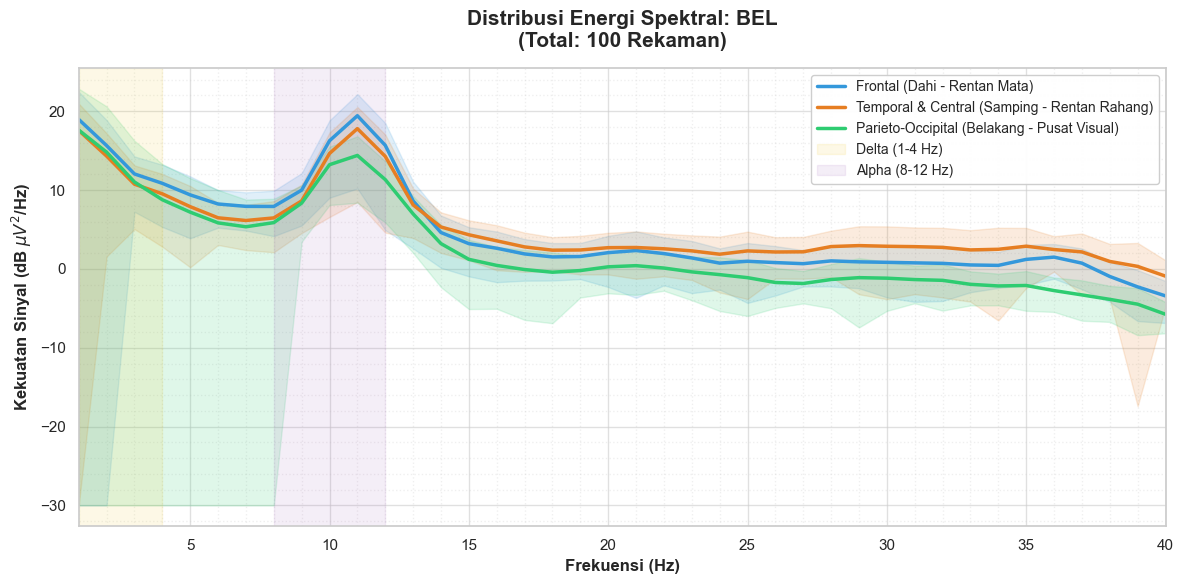

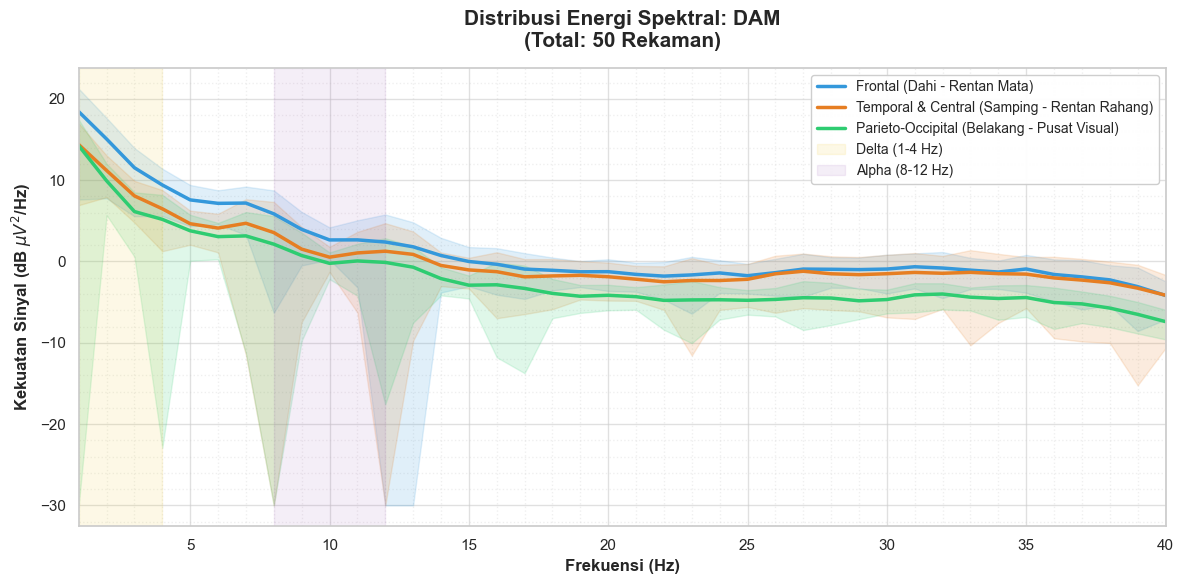

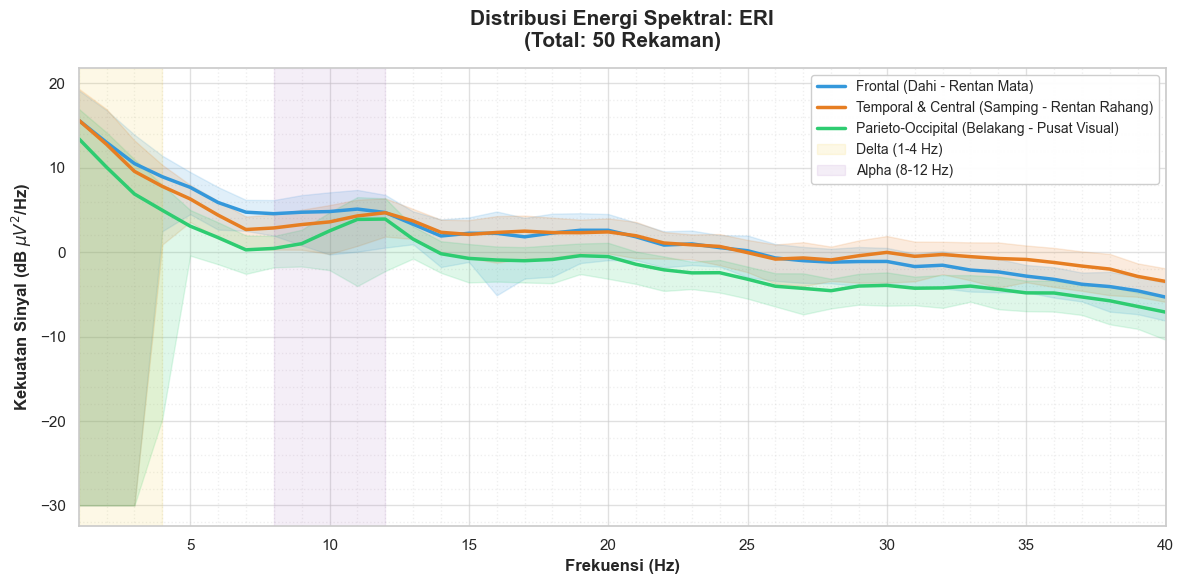

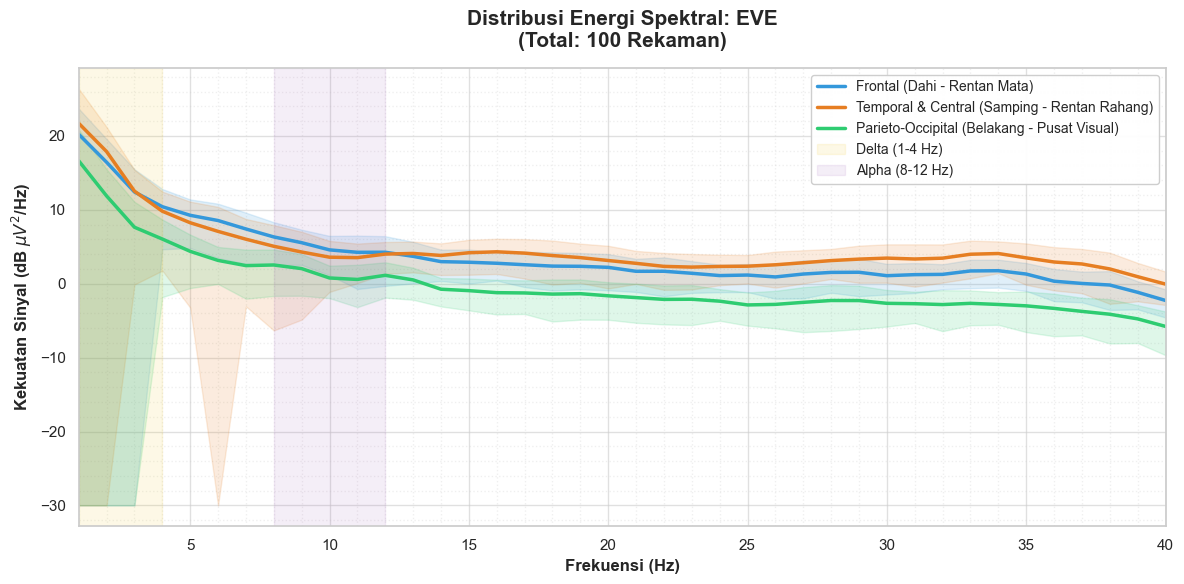

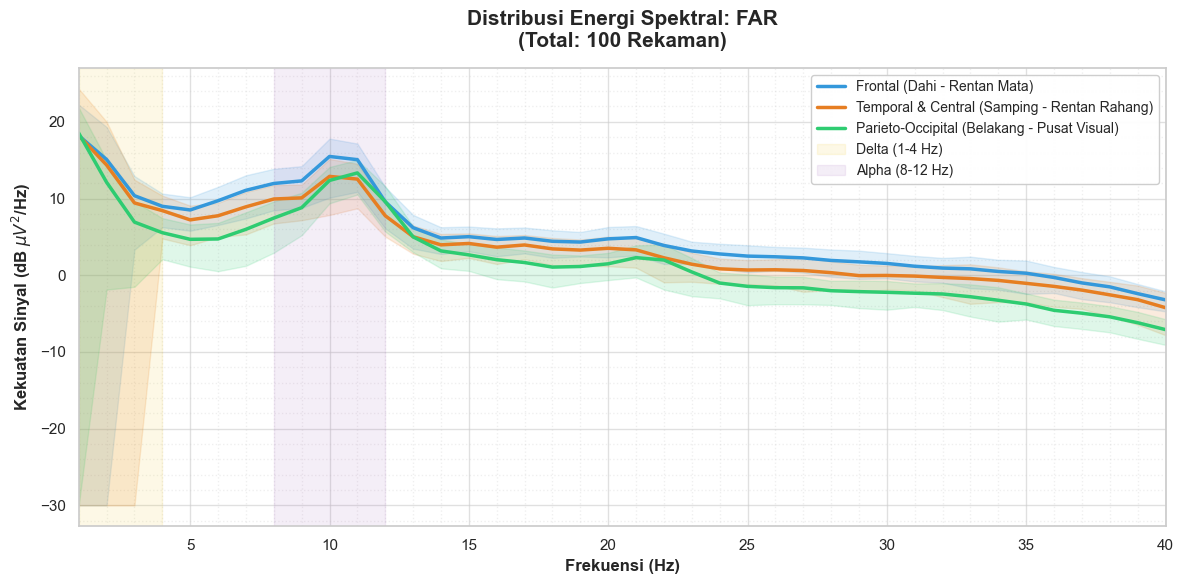

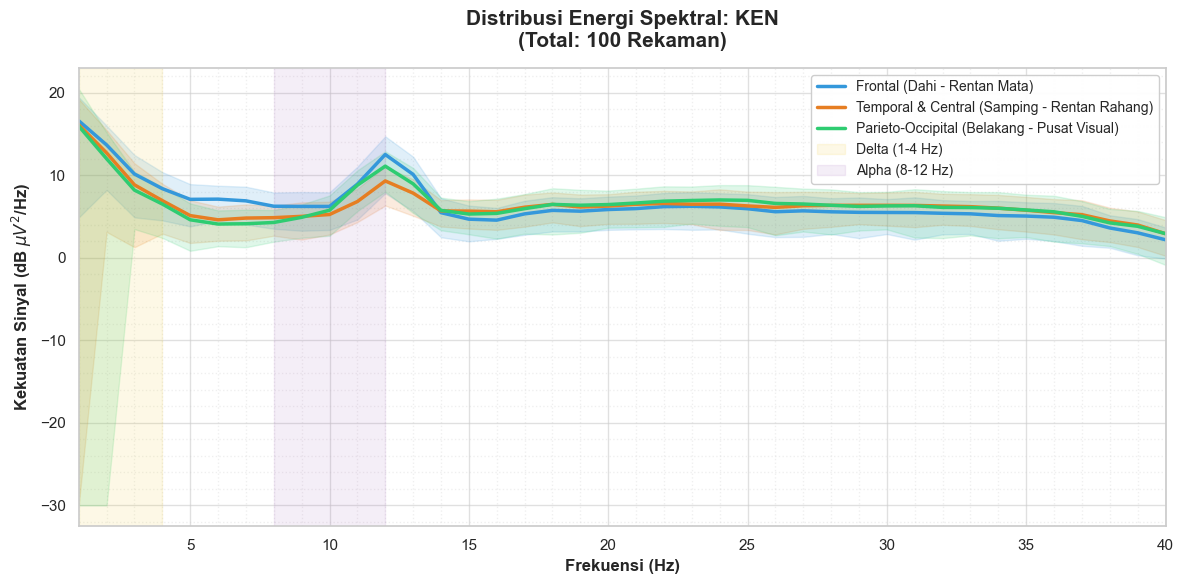

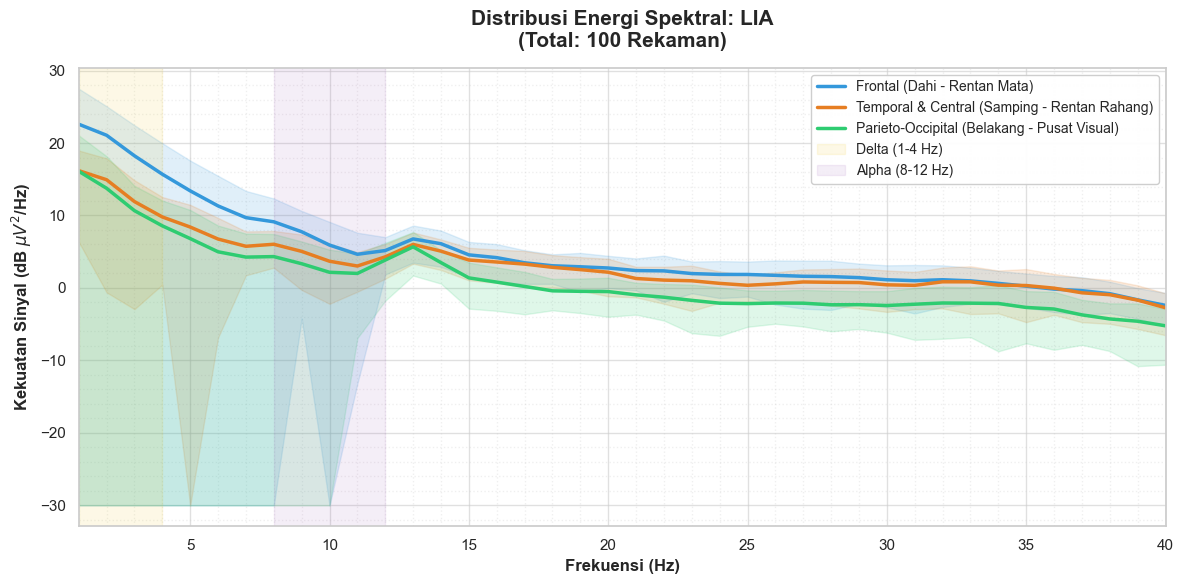

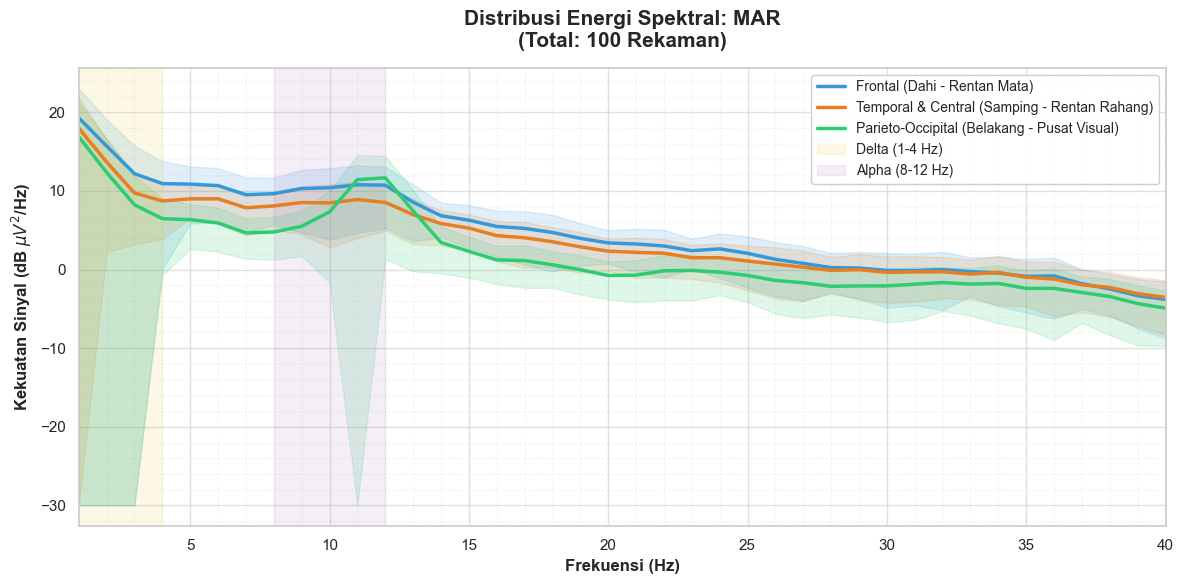

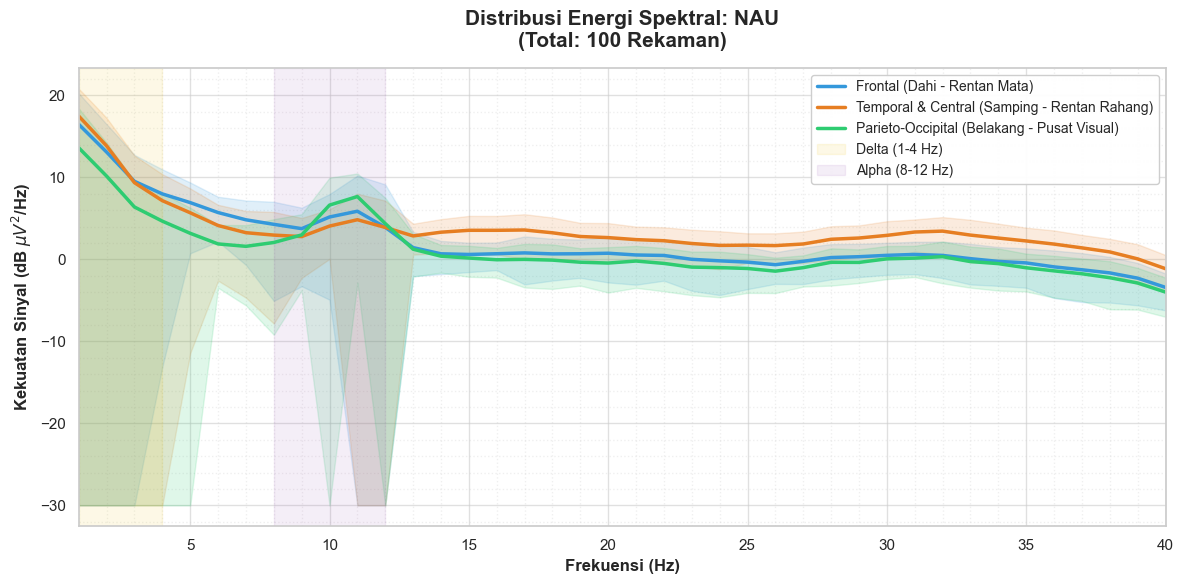

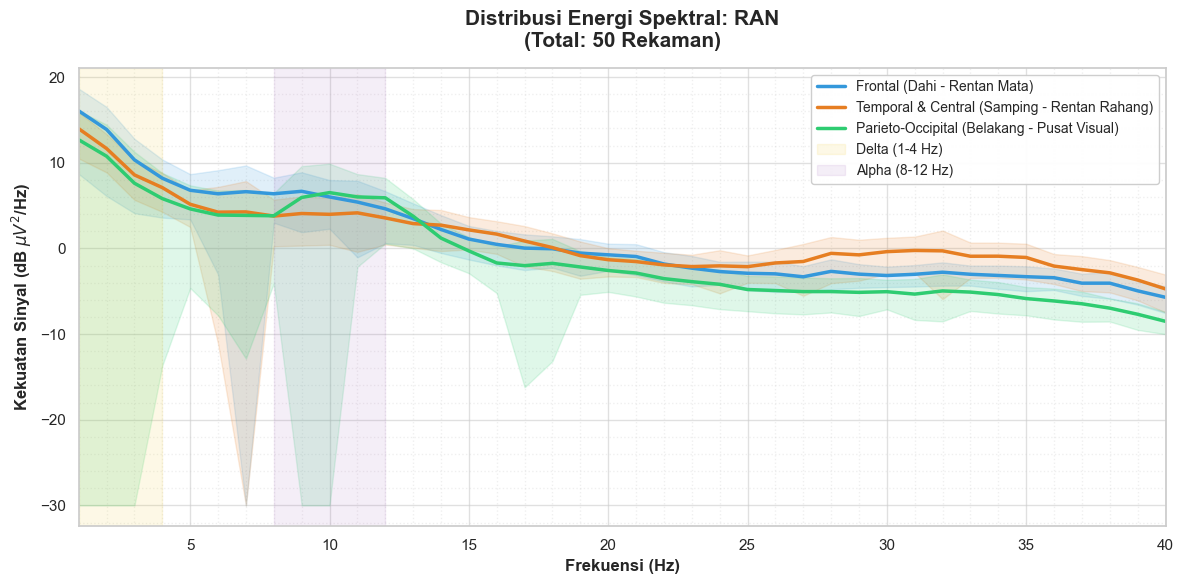

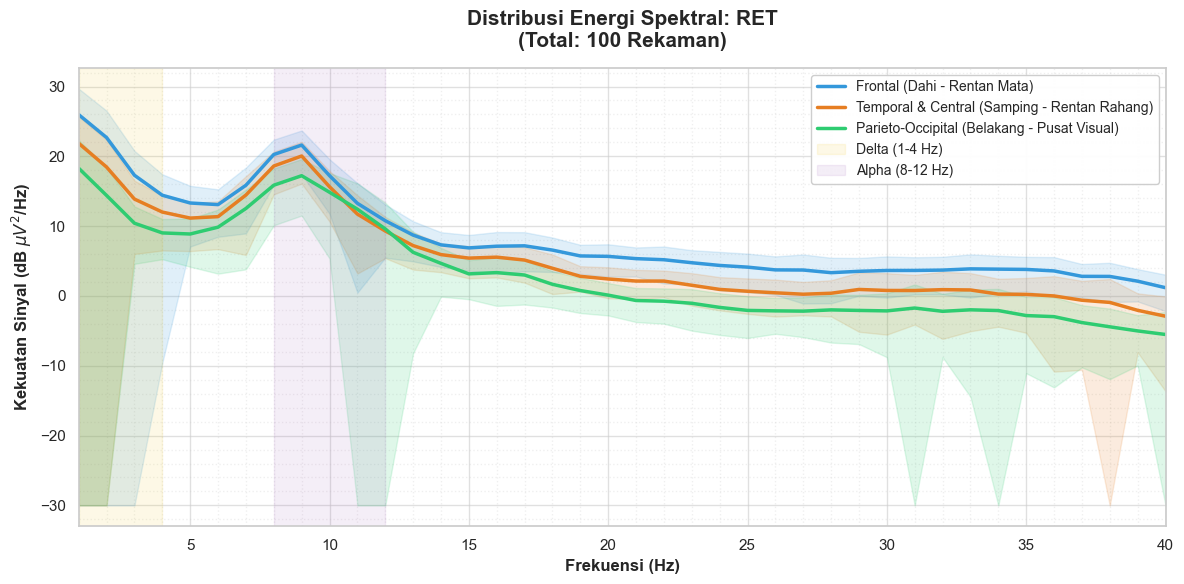

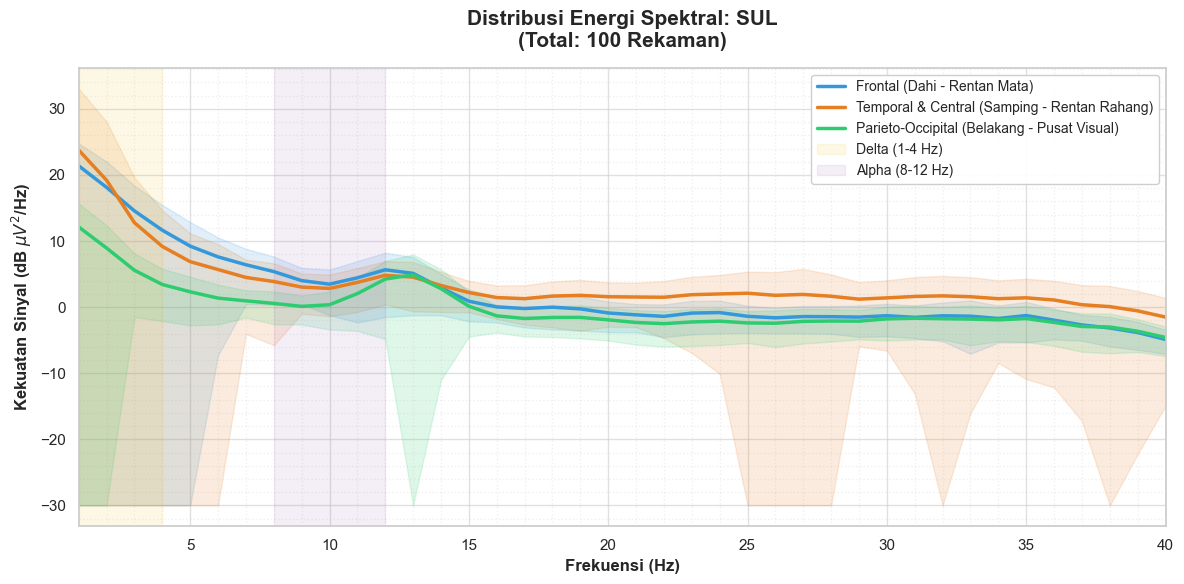

In [5]:
# =====================================================================
# TAHAP 2: ANALISIS PSD (TANPA FILTER QC KETAT)
# =====================================================================
print("\n" + "=" * 80)
print(" ANALISIS SPEKTRAL REGIONAL (EVALUASI DISTRIBUSI ASLI)")
print("=" * 80)

regions = {
    'Frontal (Dahi - Rentan Mata)': ['AF3', 'AF4', 'F3', 'F4', 'F7', 'F8'],
    'Temporal & Central (Samping - Rentan Rahang)': ['T7', 'T8', 'FC5', 'FC6'],
    'Parieto-Occipital (Belakang - Pusat Visual)': ['P7', 'P8', 'O1', 'O2']
}

subject_region_psds = {subj: {region: [] for region in regions.keys()} for subj in subjects}
subject_file_counts = {subj: 0 for subj in subjects}
freqs = None
total_processed = 0

print("Mengekstrak energi spektral dari seluruh file (QC Ketat Dimatikan)...\n")

for record in all_eeg_records:
    try:
        raw_copy = record['raw'].copy()
        raw_copy.load_data(verbose=False)
        raw_copy.filter(l_freq=1.0, h_freq=45.0, verbose=False)
        
        ch_names = raw_copy.ch_names
        has_all_eeg = all(any(ch in ch_names for ch in ch_list) for ch_list in regions.values())
        
        if has_all_eeg:
            spectrum = raw_copy.compute_psd(method='welch', fmin=1.0, fmax=40.0, 
                                            n_fft=256, n_overlap=128, verbose=False)
            psd_data, f = spectrum.get_data(return_freqs=True)
            freqs = f
            
            # Ekstrak per wilayah tanpa syarat ketat
            for region_name, ch_list in regions.items():
                valid_chs = [ch for ch in ch_list if ch in ch_names]
                ch_indices = [ch_names.index(ch) for ch in valid_chs]
                
                mean_power_raw = np.mean(psd_data[ch_indices, :], axis=0)
                subject_region_psds[record['subject']][region_name].append(mean_power_raw)
                
            subject_file_counts[record['subject']] += 1
            total_processed += 1
            
        del raw_copy 
    except Exception as e:
        pass 

print(f"✓ Berhasil mengekstrak {total_processed} file secara keseluruhan.\n")

# =====================================================================
# TAHAP 3: VISUALISASI GRAFIK GRAND AVERAGE PER SUBJEK (AUTO-SCALE Y)
# =====================================================================
print("=" * 80)
print(" VISUALISASI DISTRIBUSI SPEKTRAL PER SUBJEK")
print("=" * 80)

colors = ['#3498db', '#e67e22', '#2ecc71'] 

for subject in subjects:
    file_count = subject_file_counts[subject]
    
    if file_count > 0:
        plt.figure(figsize=(12, 6))
        
        for (region_name, ch_list), color in zip(regions.items(), colors):
            psd_list = subject_region_psds[subject][region_name]
            psd_array = np.array(psd_list)
            
            mean_psd = np.mean(psd_array, axis=0)
            mean_psd_db = 10 * np.log10(np.maximum(mean_psd * 1e12, 1e-10))
            
            # Gambar garis utama
            plt.plot(freqs, mean_psd_db, label=region_name, color=color, linewidth=2.5)
            
            # Gambar bayangan Standar Deviasi
            if file_count > 1:
                std_psd = np.std(psd_array, axis=0)
                upper_bound = 10 * np.log10(np.maximum((mean_psd + std_psd) * 1e12, 1e-10))
                lower_raw = np.maximum((mean_psd - std_psd), 1e-15) 
                lower_bound = 10 * np.log10(lower_raw * 1e12)
                plt.fill_between(freqs, lower_bound, upper_bound, color=color, alpha=0.15)

        # Arsiran fisiologis
        plt.axvspan(1, 4, color='#f1c40f', alpha=0.1, label='Delta (1-4 Hz)')
        plt.axvspan(8, 12, color='#9b59b6', alpha=0.1, label='Alpha (8-12 Hz)')

        plt.title(f"Distribusi Energi Spektral: {subject}\n(Total: {file_count} Rekaman)", fontsize=15, fontweight='bold', pad=15)
        plt.xlabel("Frekuensi (Hz)", fontsize=12, fontweight='bold')
        plt.ylabel("Kekuatan Sinyal (dB $\mu V^2$/Hz)", fontsize=12, fontweight='bold')
        plt.xlim(1, 40)
        
        # PENTING: Saya mematikan plt.ylim() agar sumbu Y menyesuaikan datanya secara otomatis!
        # plt.ylim(-10, 35) 
        
        plt.grid(True, which='major', linestyle='-', alpha=0.6)
        plt.grid(True, which='minor', linestyle=':', alpha=0.3)
        plt.minorticks_on()
        
        plt.legend(loc='upper right', fontsize=10, framealpha=0.95)
        plt.tight_layout()
        plt.show()
    else:
        print(f"[!] Subjek {subject} dilewati karena 0 file berhasil diekstrak.")